# 🌱 Crop Recommendation — Ensemble (RF + XGBoost)

**Dataset:** `Crop_recommendation_filtered.csv`  
**Features:** N, P, K, temperature, humidity, ph, rainfall  
**Target:** crop label (11 classes)  
**Models:** Random Forest + XGBoost → Weighted Soft-Voting Ensemble

---

## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

FEATURES = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
TARGET   = 'label'
SEED     = 42

# Ensemble weights
RF_WEIGHT  = 0.45
XGB_WEIGHT = 0.55

print('✓ Imports ready')

✓ Imports ready


## Cell 2 — Load Data

In [2]:
# ── Update path if needed ─────────────────────────────────────────────────────
df = pd.read_csv('Crop_recommendation_filtered4.csv')

print(f'Shape  : {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nMissing values:')
print(df.isnull().sum())
print(f'\nCrop classes ({df[TARGET].nunique()}):')
print(sorted(df[TARGET].unique()))
df.head()

Shape  : (2600, 8)
Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Missing values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Crop classes (26):
['banana', 'cabbage', 'carrot', 'cashew', 'cassava', 'coconut', 'coffee', 'cotton', 'cucumber', 'garlic', 'ginger', 'groundnut', 'guava', 'lettuce', 'maize', 'mango', 'okra', 'onion', 'orange', 'pear', 'pepper', 'rice', 'tomato', 'watermelon', 'wheat', 'yam']


,N,P,K,temperature,humidity,ph,rainfall,label
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,rice
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,rice
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,rice
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,rice
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,rice


## Cell 3 — Preprocessing

In [3]:
X = df[FEATURES].copy()
y = df[TARGET].copy()

# Encode labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
print(f'Classes ({len(encoder.classes_)}): {list(encoder.classes_)}')

# Scale features — required for good XGBoost convergence, harmless for RF
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2, random_state=SEED, stratify=y_encoded
)
print(f'\nTrain: {len(X_train):,}   Test: {len(X_test):,}')

Classes (26): ['banana', 'cabbage', 'carrot', 'cashew', 'cassava', 'coconut', 'coffee', 'cotton', 'cucumber', 'garlic', 'ginger', 'groundnut', 'guava', 'lettuce', 'maize', 'mango', 'okra', 'onion', 'orange', 'pear', 'pepper', 'rice', 'tomato', 'watermelon', 'wheat', 'yam']

Train: 2,080   Test: 520


## Cell 4 — Train Random Forest

In [4]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,         # full depth — better than capping at 10 for this dataset
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred     = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f'Random Forest Accuracy: {rf_accuracy:.4f}  ({rf_accuracy*100:.2f}%)')

Random Forest Accuracy: 0.8846  (88.46%)


## Cell 5 — Train XGBoost

In [5]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    # ── FIX: use_label_encoder removed in XGBoost ≥ 2.0 ─────────────────
    # objective must be 'multi:softprob' (not 'softmax') for predict_proba
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

xgb_pred     = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print(f'XGBoost Accuracy: {xgb_accuracy:.4f}  ({xgb_accuracy*100:.2f}%)')

XGBoost Accuracy: 0.8712  (87.12%)


## Cell 6 — Build Weighted Soft-Voting Ensemble

> **Why `voting='soft'`?**  
> Hard voting takes the majority *class*. Soft voting averages *probabilities*,
> giving us confidence scores we need for ranking the top-3 results.

In [6]:
# Equal soft-voting weights (0.5 RF + 0.5 XGBoost)
RF_WEIGHT  = 0.5
XGB_WEIGHT = 0.5

estimators = [('rf', rf_model), ('xgb', xgb_model)]
weights    = [RF_WEIGHT, XGB_WEIGHT]

# ── FIX: voting='soft' so predict_proba is available ──────────────────────────
ensemble_model = VotingClassifier(
    estimators=estimators,
    voting='soft',
    weights=weights,
    n_jobs=-1
)
ensemble_model.fit(X_train, y_train)

ensemble_pred     = ensemble_model.predict(X_test)
ensemble_accuracy = accuracy_score(y_test, ensemble_pred)
print(f'Ensemble Accuracy: {ensemble_accuracy:.4f}  ({ensemble_accuracy*100:.2f}%)')

# ── Manual confidence calculation: Final = 0.5*P_RF + 0.5*P_XGB ───────────────
rf_proba   = rf_model.predict_proba(X_test)          # shape: (n_samples, n_classes)
xgb_proba  = xgb_model.predict_proba(X_test)         # shape: (n_samples, n_classes)
ens_proba  = 0.5 * rf_proba + 0.5 * xgb_proba        # element-wise blend

# Final prediction from blended probabilities
manual_pred     = np.argmax(ens_proba, axis=1)
manual_accuracy = accuracy_score(y_test, manual_pred)
print(f'Manual 0.5/0.5 Blend Accuracy: {manual_accuracy:.4f}  ({manual_accuracy*100:.2f}%)')

# Per-sample top confidence (the max blended probability for each test sample)
sample_confidence = ens_proba.max(axis=1)
print(f'\nConfidence Statistics (across {len(X_test)} test samples):')
print(f'  Mean  confidence : {sample_confidence.mean()*100:.2f}%')
print(f'  Median confidence: {np.median(sample_confidence)*100:.2f}%')
print(f'  Min   confidence : {sample_confidence.min()*100:.2f}%')
print(f'  Max   confidence : {sample_confidence.max()*100:.2f}%')


Ensemble Accuracy: 0.8827  (88.27%)
Manual 0.5/0.5 Blend Accuracy: 0.8788  (87.88%)

Confidence Statistics (across 520 test samples):
  Mean  confidence : 85.85%
  Median confidence: 93.60%
  Min   confidence : 27.46%
  Max   confidence : 99.98%


## Cell 7 — Accuracy Comparison

In [7]:
print(f'Random Forest Accuracy       : {rf_accuracy:.4f}  ({rf_accuracy*100:.2f}%)')
print(f'XGBoost Accuracy             : {xgb_accuracy:.4f}  ({xgb_accuracy*100:.2f}%)')
print(f'Ensemble Accuracy (sklearn)  : {ensemble_accuracy:.4f}  ({ensemble_accuracy*100:.2f}%)')
print(f'Ensemble Accuracy (manual)   : {manual_accuracy:.4f}  ({manual_accuracy*100:.2f}%)')


Random Forest Accuracy       : 0.8846  (88.46%)
XGBoost Accuracy             : 0.8712  (87.12%)
Ensemble Accuracy (sklearn)  : 0.8827  (88.27%)
Ensemble Accuracy (manual)   : 0.8788  (87.88%)


## Cell 8 — Classification Report

In [8]:
print('Classification Report (Ensemble):')
print(classification_report(y_test, ensemble_pred, target_names=encoder.classes_))

Classification Report (Ensemble):
              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        20
     cabbage       0.86      0.90      0.88        20
      carrot       0.89      0.85      0.87        20
      cashew       0.90      0.95      0.93        20
     cassava       0.90      0.90      0.90        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
    cucumber       0.82      0.70      0.76        20
      garlic       0.43      0.50      0.47        20
      ginger       0.91      1.00      0.95        20
   groundnut       1.00      1.00      1.00        20
       guava       0.81      0.65      0.72        20
     lettuce       1.00      0.80      0.89        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
        okra       1.00      0.80      0.89    

## Cell 8b — Precision, Recall, F1 & Confusion Matrix

  ENSEMBLE MODEL — EVALUATION METRICS
  Accuracy  : 88.27%
  Precision : 89.05%  (macro avg)
  Recall    : 88.27%  (macro avg)
  F1 Score  : 88.42%  (macro avg)

Per-class metrics:
              precision  recall  f1-score   support
banana           1.0000  1.0000    1.0000   20.0000
cabbage          0.8571  0.9000    0.8780   20.0000
carrot           0.8947  0.8500    0.8718   20.0000
cashew           0.9048  0.9500    0.9268   20.0000
cassava          0.9000  0.9000    0.9000   20.0000
coconut          1.0000  1.0000    1.0000   20.0000
coffee           1.0000  1.0000    1.0000   20.0000
cotton           1.0000  1.0000    1.0000   20.0000
cucumber         0.8235  0.7000    0.7568   20.0000
garlic           0.4348  0.5000    0.4651   20.0000
ginger           0.9091  1.0000    0.9524   20.0000
groundnut        1.0000  1.0000    1.0000   20.0000
guava            0.8125  0.6500    0.7222   20.0000
lettuce          1.0000  0.8000    0.8889   20.0000
maize            1.0000  1.0000    1.00

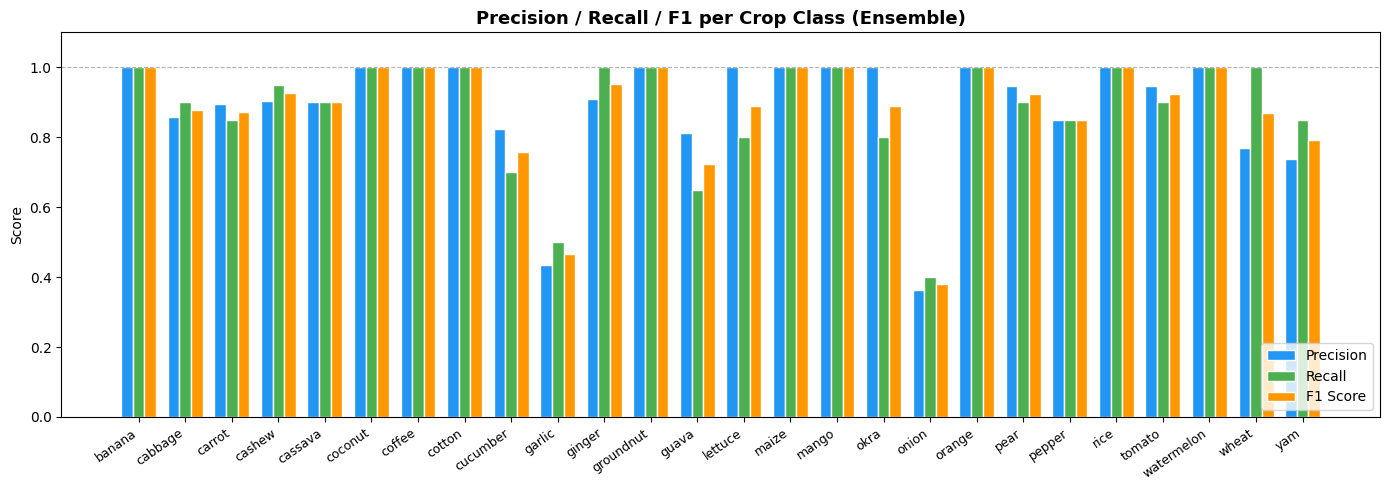

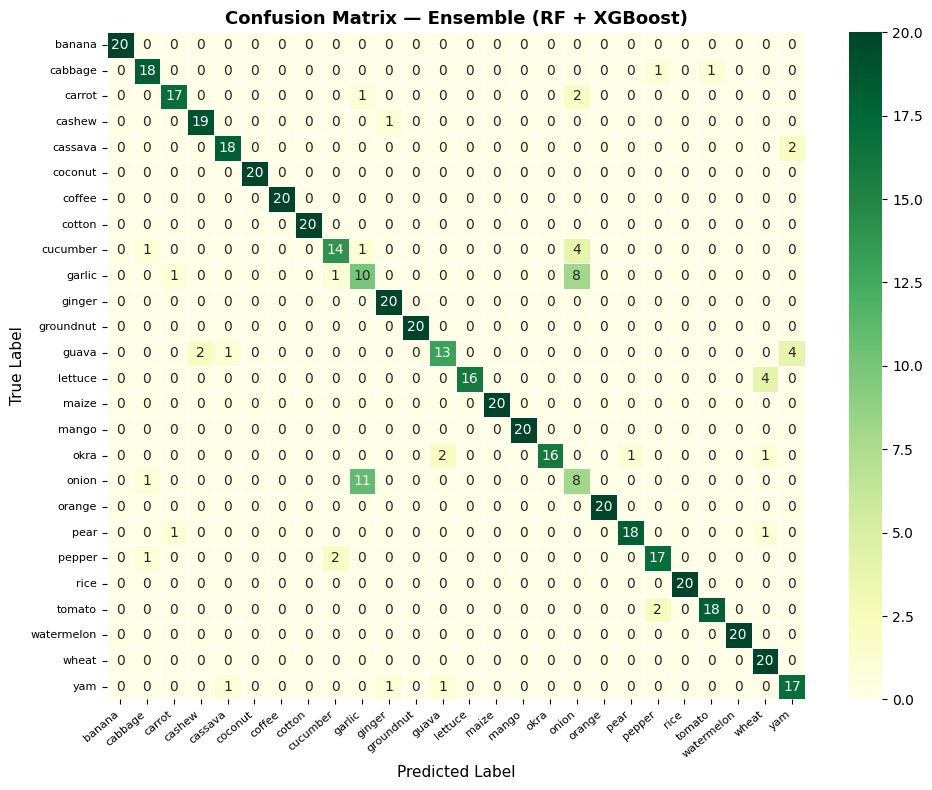

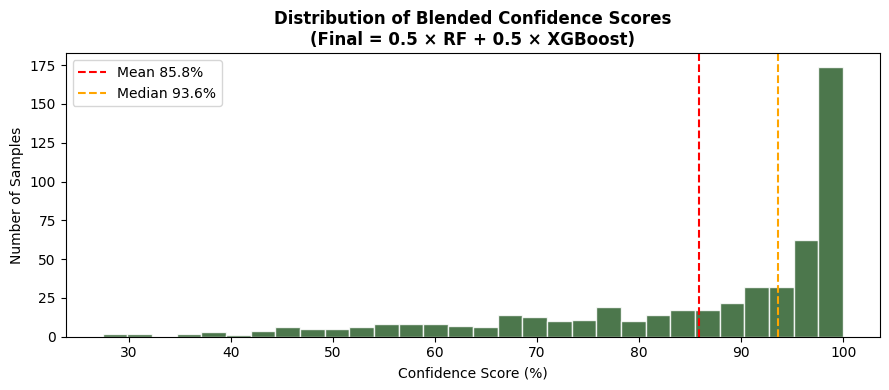

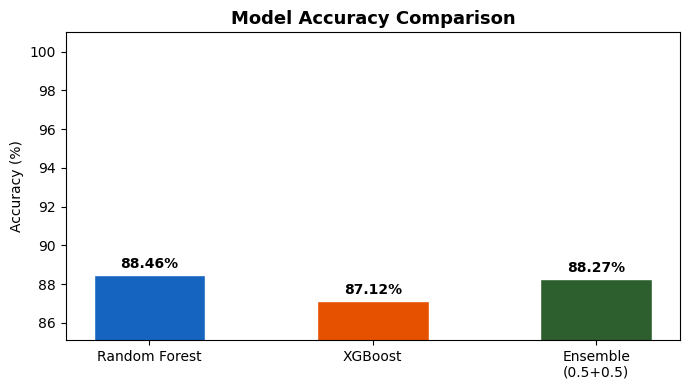

In [9]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             ConfusionMatrixDisplay)

# ── Scalar scores (macro-averaged across all 11 classes) ──────────────────────
precision = precision_score(y_test, ensemble_pred, average='macro')
recall    = recall_score(y_test, ensemble_pred, average='macro')
f1        = f1_score(y_test, ensemble_pred, average='macro')

print("=" * 52)
print("  ENSEMBLE MODEL — EVALUATION METRICS")
print("=" * 52)
print(f"  Accuracy  : {ensemble_accuracy*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%  (macro avg)")
print(f"  Recall    : {recall*100:.2f}%  (macro avg)")
print(f"  F1 Score  : {f1*100:.2f}%  (macro avg)")
print("=" * 52)

# ── Per-class table ───────────────────────────────────────────────────────────
report_df = pd.DataFrame(
    classification_report(
        y_test, ensemble_pred,
        target_names=encoder.classes_,
        output_dict=True
    )
).T.round(4)
print("\nPer-class metrics:")
print(report_df[['precision', 'recall', 'f1-score', 'support']].to_string())

# ── Figure 1: Precision / Recall / F1 per class (grouped bar) ─────────────────
class_report = classification_report(
    y_test, ensemble_pred,
    target_names=encoder.classes_,
    output_dict=True
)
classes   = encoder.classes_
prec_vals = [class_report[c]['precision'] for c in classes]
rec_vals  = [class_report[c]['recall']    for c in classes]
f1_vals   = [class_report[c]['f1-score']  for c in classes]

x     = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, prec_vals, width, label='Precision', color='#2196F3', edgecolor='white')
ax.bar(x,         rec_vals,  width, label='Recall',    color='#4CAF50', edgecolor='white')
ax.bar(x + width, f1_vals,   width, label='F1 Score',  color='#FF9800', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=35, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 per Crop Class (Ensemble)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

# ── Figure 2: Confusion Matrix ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, ensemble_pred)
sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    cmap='YlGn',
    linewidths=0.4,
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label',      fontsize=11)
ax.set_title('Confusion Matrix — Ensemble (RF + XGBoost)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=8)
plt.tight_layout()
plt.show()

# ── Figure 3: Per-sample Confidence Distribution ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sample_confidence * 100, bins=30, color='#2C5F2D', edgecolor='white', alpha=0.85)
ax.axvline(sample_confidence.mean() * 100, color='red',    linestyle='--', linewidth=1.5,
           label=f'Mean {sample_confidence.mean()*100:.1f}%')
ax.axvline(np.median(sample_confidence) * 100, color='orange', linestyle='--', linewidth=1.5,
           label=f'Median {np.median(sample_confidence)*100:.1f}%')
ax.set_xlabel('Confidence Score (%)')
ax.set_ylabel('Number of Samples')
ax.set_title('Distribution of Blended Confidence Scores\n(Final = 0.5 × RF + 0.5 × XGBoost)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# ── Figure 4: Accuracy comparison bar ─────────────────────────────────────────
model_names  = ['Random Forest', 'XGBoost', 'Ensemble\n(0.5+0.5)']
model_scores = [rf_accuracy * 100, xgb_accuracy * 100, ensemble_accuracy * 100]
colours      = ['#1565C0', '#E65100', '#2C5F2D']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(model_names, model_scores, color=colours, edgecolor='white', width=0.5)
ax.set_ylim(min(model_scores) - 2, 101)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
for bar, score in zip(bars, model_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{score:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


## Cell 9 — Feature Importance

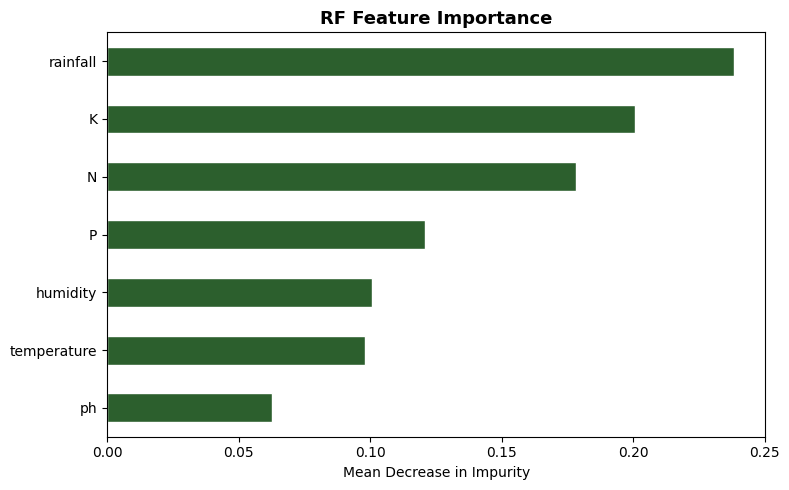

In [10]:
importance = rf_model.feature_importances_
feat_series = pd.Series(importance, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_series.plot(kind='barh', ax=ax, color='#2C5F2D', edgecolor='white')
ax.set_title('RF Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

## Cell 10 — Save Model

In [11]:
import joblib, os

os.makedirs('outputs', exist_ok=True)
joblib.dump(ensemble_model, 'outputs/crop_prediction_model.pkl')
joblib.dump(encoder,        'outputs/label_encoder.pkl')
joblib.dump(scaler,         'outputs/scaler.pkl')
print('✓ Model, encoder, and scaler saved to outputs/')

✓ Model, encoder, and scaler saved to outputs/


## Cell 11 — Load Model (Optional)

Run this cell if you want to reload saved artifacts in a fresh session.

In [12]:
import joblib

ensemble_model = joblib.load('outputs/crop_prediction_model.pkl')
encoder        = joblib.load('outputs/label_encoder.pkl')
scaler         = joblib.load('outputs/scaler.pkl')
print('✓ Model loaded successfully')

✓ Model loaded successfully


---
## Cell 12 — `predict_crop()` — Top-3 Results in Descending Confidence

Returns the **top 3 recommended crops** ranked by confidence score (highest first).  
All 7 features are required and must be valid numbers.

In [13]:
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    """
    Recommend the top 3 crops for the given soil/climate conditions.

    Parameters
    ----------
    N           : Nitrogen content in soil       (kg/ha)
    P           : Phosphorous content in soil    (kg/ha)
    K           : Potassium content in soil      (kg/ha)
    temperature : Mean temperature               (°C)
    humidity    : Relative humidity              (%)
    ph          : Soil pH                        (0–14)
    rainfall    : Annual rainfall                (mm)

    Returns
    -------
    list of (crop_name, confidence_pct) tuples, descending order
    """
    sample        = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    sample_scaled = scaler.transform(sample)

    # Blended soft-vote probabilities
    proba     = ensemble_model.predict_proba(sample_scaled)[0]  # shape: (n_classes,)
    top3_idx  = np.argsort(proba)[::-1][:3]                     # indices of top 3
    top3      = [(encoder.classes_[i], round(proba[i] * 100, 2)) for i in top3_idx]

    print(f'\n{"─"*52}')
    print(f'  Input  →  N={N}  P={P}  K={K}  Temp={temperature}°C')
    print(f'            Humidity={humidity}%  pH={ph}  Rainfall={rainfall}mm')
    print(f'{"─"*52}')
    print(f'  TOP 3 RECOMMENDATIONS (descending confidence):')
    for rank, (crop, pct) in enumerate(top3, 1):
        bar = '█' * int(pct / 4)
        print(f'  {rank}. {crop:<14}  {pct:6.2f}%  {bar}')
    print(f'{"─"*52}\n')
    return top3


# ── Demo predictions ──────────────────────────────────────────────────────────
predict_crop(N=90, P=42, K=43, temperature=25, humidity=80, ph=6.5, rainfall=200)
predict_crop(N=16, P=143, K=204, temperature=23, humidity=92, ph=5.8, rainfall=115)


────────────────────────────────────────────────────
  Input  →  N=90  P=42  K=43  Temp=25°C
            Humidity=80%  pH=6.5  Rainfall=200mm
────────────────────────────────────────────────────
  TOP 3 RECOMMENDATIONS (descending confidence):
  1. rice             94.50%  ███████████████████████
  2. lettuce           1.27%  
  3. coffee            1.26%  
────────────────────────────────────────────────────


────────────────────────────────────────────────────
  Input  →  N=16  P=143  K=204  Temp=23°C
            Humidity=92%  pH=5.8  Rainfall=115mm
────────────────────────────────────────────────────
  TOP 3 RECOMMENDATIONS (descending confidence):
  1. coconut          23.58%  █████
  2. banana           17.05%  ████
  3. carrot           16.94%  ████
────────────────────────────────────────────────────



[('coconut', np.float64(23.58)),
 ('banana', np.float64(17.05)),
 ('carrot', np.float64(16.94))]

---
## Cell 13 — `predict_crop_fuzzy()` — Smart Fallback for Missing / Out-of-Range Inputs

**Logic:**
1. First tries the normal model prediction (top-3 confidence).
2. If the top confidence is very low **or** any inputs are `None` / `NaN`, it
   activates **fuzzy nearest-neighbour mode**:
   - Known columns are normalised and distance is computed only on those.
   - Unknown/missing columns are filled from the closest matching rows in the dataset.
   - The top-3 crops are selected by a **combined score** = closeness (1 − distance) × model confidence.
3. The output always shows 3 crops in descending score order, and clearly marks
   which columns were imputed.

In [14]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import euclidean_distances

# ── Pre-compute dataset-level stats for normalisation ─────────────────────────
_df_feat    = df[FEATURES].values.astype(float)
_df_labels  = df[TARGET].values
_col_mins   = _df_feat.min(axis=0)
_col_maxs   = _df_feat.max(axis=0)
_col_ranges = np.where(_col_maxs - _col_mins == 0, 1.0, _col_maxs - _col_mins)

CONF_THRESHOLD = 0.30   # below this the model is "not confident" → try fuzzy


def predict_crop_fuzzy(N=None, P=None, K=None,
                       temperature=None, humidity=None,
                       ph=None, rainfall=None):
    """
    Recommend the top 3 crops.

    Accepts None or NaN for any parameter.
    - If all parameters are provided AND the model is confident → standard top-3.
    - If any parameter is missing OR model confidence is low → fuzzy mode:
        * Finds the k nearest dataset rows using only the known columns.
        * Fills missing columns from those neighbours.
        * Ranks crops by closeness × model confidence.

    Parameters (all optional, pass None to indicate 'unknown')
    -----------------------------------------------------------
    N           : Nitrogen       (kg/ha)
    P           : Phosphorous    (kg/ha)
    K           : Potassium      (kg/ha)
    temperature : Temperature    (°C)
    humidity    : Humidity       (%)
    ph          : Soil pH        (0–14)
    rainfall    : Rainfall       (mm)
    """
    raw_vals   = [N, P, K, temperature, humidity, ph, rainfall]
    known_mask = np.array([v is not None and not (isinstance(v, float) and np.isnan(v))
                           for v in raw_vals])
    missing_cols = [FEATURES[i] for i in range(len(FEATURES)) if not known_mask[i]]

    # ── Case 1: all inputs provided ───────────────────────────────────────────
    if known_mask.all():
        sample        = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
        sample_scaled = scaler.transform(sample)
        proba         = ensemble_model.predict_proba(sample_scaled)[0]
        top_conf      = proba.max()

        if top_conf >= CONF_THRESHOLD:
            # Standard path — high confidence
            top3_idx = np.argsort(proba)[::-1][:3]
            top3     = [(encoder.classes_[i], round(proba[i] * 100, 2)) for i in top3_idx]
            _print_results(raw_vals, top3, missing_cols, mode='standard')
            return top3
        # else fall through to fuzzy with all values known but low confidence

    # ── Case 2: fuzzy / missing-input mode ────────────────────────────────────
    known_indices = np.where(known_mask)[0]

    # Normalise the input on known columns
    raw_arr       = np.array([v if v is not None else np.nan for v in raw_vals], dtype=float)
    norm_input    = (raw_arr[known_indices] - _col_mins[known_indices]) / _col_ranges[known_indices]
    norm_dataset  = (_df_feat[:, known_indices] - _col_mins[known_indices]) / _col_ranges[known_indices]

    # Euclidean distance on known dims only
    dists   = np.sqrt(((norm_dataset - norm_input) ** 2).sum(axis=1))  # shape (n_rows,)

    # Take top-K nearest neighbours (enough to get good crop diversity)
    K_NEIGH = 50
    nn_idx  = np.argsort(dists)[:K_NEIGH]

    # For each neighbour, fill missing columns and run model
    scores = {}   # crop → best combined score
    imputed_suggestions = {}  # crop → one example of filled values

    for idx in nn_idx:
        filled = raw_arr.copy()
        for j in range(len(FEATURES)):
            if not known_mask[j] or np.isnan(filled[j]):
                filled[j] = _df_feat[idx, j]   # borrow from neighbour

        fs           = scaler.transform(filled.reshape(1, -1))
        proba        = ensemble_model.predict_proba(fs)[0]
        top_class    = encoder.classes_[proba.argmax()]
        top_conf     = proba.max()
        closeness    = 1.0 / (1.0 + dists[idx])   # 0→1, higher=closer
        combined     = closeness * top_conf

        # Keep the best combined score for each crop
        if top_class not in scores or combined > scores[top_class]:
            scores[top_class]             = combined
            imputed_suggestions[top_class] = filled

    # Sort by combined score, take top 3
    sorted_crops = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:3]

    # Build final list with confidence % (re-run model on best imputed row)
    top3 = []
    for crop, _ in sorted_crops:
        best_filled  = imputed_suggestions[crop]
        fs           = scaler.transform(best_filled.reshape(1, -1))
        proba        = ensemble_model.predict_proba(fs)[0]
        conf_pct     = round(proba.max() * 100, 2)
        top3.append((crop, conf_pct))

    _print_results(raw_vals, top3, missing_cols,
                   mode='fuzzy',
                   imputed_suggestions=imputed_suggestions)
    return top3


# ── Pretty-printer ─────────────────────────────────────────────────────────────
def _print_results(raw_vals, top3, missing_cols, mode='standard',
                   imputed_suggestions=None):
    labels = ['N', 'P', 'K', 'Temp', 'Humidity', 'pH', 'Rainfall']
    units  = ['', '', '', '°C', '%', '', 'mm']
    parts  = []
    for i, (lbl, unit, v) in enumerate(zip(labels, units, raw_vals)):
        if v is None or (isinstance(v, float) and np.isnan(v)):
            parts.append(f'{lbl}=⬜')
        else:
            parts.append(f'{lbl}={v}{unit}')

    width = 58
    print(f'\n{"─"*width}')
    print(f'  Input  : {"  ".join(parts[:4])}')
    print(f'           {"  ".join(parts[4:])}')

    if mode == 'fuzzy':
        tag = '⚡ FUZZY MODE'
        if missing_cols:
            tag += f' (missing: {", ".join(missing_cols)})'
        else:
            tag += ' (low confidence — nearest-neighbour assist)'
        print(f'  {tag}')

    print(f'{"─"*width}')
    print(f'  TOP 3 RECOMMENDATIONS (descending score):')
    for rank, (crop, pct) in enumerate(top3, 1):
        bar  = '█' * int(pct / 4)
        note = ''
        if mode == 'fuzzy' and imputed_suggestions and crop in imputed_suggestions:
            filled = imputed_suggestions[crop]
            imp    = [FEATURES[j] for j in range(len(FEATURES))
                      if raw_vals[j] is None or
                      (isinstance(raw_vals[j], float) and np.isnan(raw_vals[j]))]
            if imp:
                vals_str = ', '.join(f'{c}={filled[FEATURES.index(c)]:.2f}' for c in imp)
                note     = f'  ← imputed: {vals_str}'
        print(f'  {rank}. {crop:<15}  {pct:6.2f}%  {bar}{note}')
    print(f'{"─"*width}\n')


print('✓ predict_crop_fuzzy() defined')

✓ predict_crop_fuzzy() defined


---
## Cell 14 — Demo: Standard Prediction (all values known)

In [15]:
# All 7 values provided — uses normal ensemble path
predict_crop_fuzzy(N=90, P=42, K=43, temperature=25, humidity=80, ph=6.5, rainfall=200)
predict_crop_fuzzy(N=16, P=143, K=204, temperature=23, humidity=92, ph=5.8, rainfall=115)


──────────────────────────────────────────────────────────
  Input  : N=90  P=42  K=43  Temp=25°C
           Humidity=80%  pH=6.5  Rainfall=200mm
──────────────────────────────────────────────────────────
  TOP 3 RECOMMENDATIONS (descending score):
  1. rice              94.50%  ███████████████████████
  2. lettuce            1.27%  
  3. coffee             1.26%  
──────────────────────────────────────────────────────────


──────────────────────────────────────────────────────────
  Input  : N=16  P=143  K=204  Temp=23°C
           Humidity=92%  pH=5.8  Rainfall=115mm
  ⚡ FUZZY MODE (low confidence — nearest-neighbour assist)
──────────────────────────────────────────────────────────
  TOP 3 RECOMMENDATIONS (descending score):
  1. coconut           23.58%  █████
──────────────────────────────────────────────────────────



[('coconut', np.float64(23.58))]

## Cell 15 — Demo: Missing / Out-of-Range Inputs (Fuzzy Mode)

In [16]:
# ph and rainfall unknown → fuzzy mode fills them from nearest neighbours
predict_crop_fuzzy(N=90, P=42, K=43, temperature=25, humidity=80,
                   ph=None, rainfall=None)

# Only temperature known — everything else missing
predict_crop_fuzzy(N=None, P=None, K=None, temperature=22,
                   humidity=None, ph=None, rainfall=None)

# Extreme/out-of-dataset values → low model confidence → fuzzy assist
predict_crop_fuzzy(N=999, P=999, K=999, temperature=50, humidity=5, ph=1.0, rainfall=1000)


──────────────────────────────────────────────────────────
  Input  : N=90  P=42  K=43  Temp=25°C
           Humidity=80%  pH=⬜  Rainfall=⬜
  ⚡ FUZZY MODE (missing: ph, rainfall)
──────────────────────────────────────────────────────────
  TOP 3 RECOMMENDATIONS (descending score):
  1. rice              95.49%  ███████████████████████  ← imputed: ph=5.95, rainfall=267.98
  2. wheat             87.07%  █████████████████████  ← imputed: ph=7.20, rainfall=626.98
──────────────────────────────────────────────────────────


──────────────────────────────────────────────────────────
  Input  : N=⬜  P=⬜  K=⬜  Temp=22°C
           Humidity=⬜  pH=⬜  Rainfall=⬜
  ⚡ FUZZY MODE (missing: N, P, K, humidity, ph, rainfall)
──────────────────────────────────────────────────────────
  TOP 3 RECOMMENDATIONS (descending score):
  1. rice              99.07%  ████████████████████████  ← imputed: N=65.00, P=60.00, K=43.00, humidity=81.90, ph=5.66, rainfall=227.36
  2. wheat             98.94%  ███████████

[('tomato', np.float64(66.9)),
 ('pepper', np.float64(9.17)),
 ('cabbage', np.float64(8.65))]

---
## Cell 16 — 🔧 Enter Your Own Values

Set any unknown values to `None`.

In [17]:
# ── Edit these values ─────────────────────────────────────────────────────────
my_N           = 80
my_P           = 50
my_K           = 40
my_temperature = 22.0
my_humidity    = None    # ← set to None if you don't know
my_ph          = 6.5
my_rainfall    = None    # ← set to None if you don't know

predict_crop_fuzzy(
    N=my_N, P=my_P, K=my_K,
    temperature=my_temperature,
    humidity=my_humidity,
    ph=my_ph,
    rainfall=my_rainfall
)


──────────────────────────────────────────────────────────
  Input  : N=80  P=50  K=40  Temp=22.0°C
           Humidity=⬜  pH=6.5  Rainfall=⬜
  ⚡ FUZZY MODE (missing: humidity, rainfall)
──────────────────────────────────────────────────────────
  TOP 3 RECOMMENDATIONS (descending score):
  1. rice              96.33%  ████████████████████████  ← imputed: humidity=83.46, rainfall=194.27
  2. wheat             67.26%  ████████████████  ← imputed: humidity=89.57, rainfall=729.76
  3. lettuce           46.76%  ███████████  ← imputed: humidity=67.70, rainfall=575.94
──────────────────────────────────────────────────────────



[('rice', np.float64(96.33)),
 ('wheat', np.float64(67.26)),
 ('lettuce', np.float64(46.76))]